# Nairobi Healthcare Accessibility

**Author:** Huang Duo

**Research question:** How does healthcare accessibility differ between wealthy neighbourhoods (Karen, Westlands) and informal settlements (Kibera, Mathare) in Nairobi?

**Data required before running:**
- `Data/raw/kenya-260510-free/gis_osm_pois_free_1.shp` — from Geofabrik Kenya download
- `Data/raw/ken_pop_2020_CN_100m_R2025A_v1.tif` — WorldPop Kenya 2020 constrained 100m raster

In [22]:
import geopandas as gpd
import osmnx as ox
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import h3
import rasterio
from rasterstats import zonal_stats
from shapely.geometry import Polygon, Point
from shapely.ops import unary_union
import warnings
warnings.filterwarnings('ignore')

# Paths
POI_PATH    = '../Data/raw/kenya-260510-free/gis_osm_pois_free_1.shp'
POP_RASTER  = '../Data/raw/ken_pop_2020_CN_100m_R2025A_v1.tif'
WALK_GRAPH  = '../Data/processed/nairobi_walk.graphml'

## Step 1 — Load boundaries & filter OSM data

Nairobi CRS: epsg:4326


<Axes: >

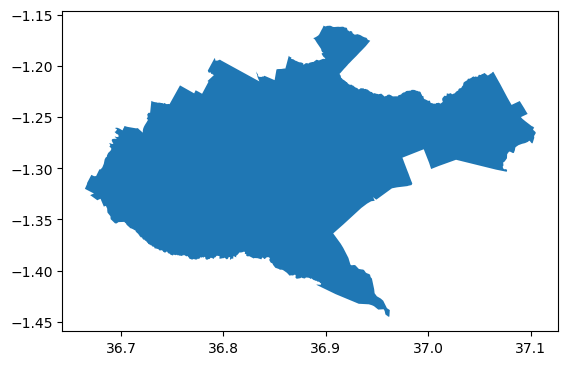

In [32]:
# Nairobi city boundary
nairobi = ox.geocode_to_gdf('Nairobi, Kenya')
nairobi_poly = nairobi.geometry.values[0]
print('Nairobi CRS:', nairobi.crs)
nairobi.plot()

In [33]:
# Four study areas
area_names = ['Karen', 'Westlands', 'Kibera', 'Mathare']
area_colors = {
    'Karen':     '#1f77b4',
    'Westlands': '#2ca02c',
    'Kibera':    '#d62728',
    'Mathare':   '#ff7f0e',
}

areas = {}
for name in area_names:
    # Kibera was officially renamed to "Kibra" in OSM — query under new name
    osm_name = 'Kibra' if name == 'Kibera' else name
    try:
        areas[name] = ox.geocode_to_gdf(f'{osm_name}, Nairobi, Kenya')
        geom_type = areas[name].geometry.values[0].geom_type
        print(f'{name}: OK ({geom_type})')
    except Exception as e:
        print(f'{name}: FAILED — {e}')


Karen: OK (Polygon)
Westlands: OK (Polygon)
Kibera: OK (Polygon)
Mathare: OK (Polygon)


In [35]:
# Load Kenya OSM POI and filter to health facilities
kenya_pois = gpd.read_file(POI_PATH)
print('POI columns:', kenya_pois.columns.tolist())
print('fclass values (top 30):'); print(kenya_pois['fclass'].value_counts().head(30))

POI columns: ['osm_id', 'code', 'fclass', 'name', 'geometry']
fclass values (top 30):
fclass
toilet              16055
school               7318
drinking_water       3425
water_well           3076
restaurant           2109
kindergarten         2073
marketplace          1829
hotel                1669
shelter              1196
bank                 1043
kiosk                1020
pharmacy              728
bar                   687
clinic                653
supermarket           631
convenience           490
guesthouse            457
tourist_info          455
community_centre      450
hospital              438
police                401
pub                   380
clothes               371
butcher               349
chemist               346
camp_site             336
cafe                  330
hairdresser           322
hostel                274
comms_tower           236
Name: count, dtype: int64


In [36]:
# Filter health facility types
health_types = ['hospital', 'clinic', 'pharmacy', 'doctors']
kenya_health = kenya_pois[kenya_pois['fclass'].isin(health_types)].copy()

# Ensure CRS matches
kenya_health = kenya_health.to_crs(nairobi.crs)

# Clip to Nairobi
nairobi_health = gpd.sjoin(kenya_health, nairobi[['geometry']], predicate='within').drop(columns='index_right')
print(f'Nairobi health facilities: {len(nairobi_health)}')
print(nairobi_health['fclass'].value_counts())

Nairobi health facilities: 980
fclass
pharmacy    475
clinic      351
hospital    146
doctors       8
Name: count, dtype: int64


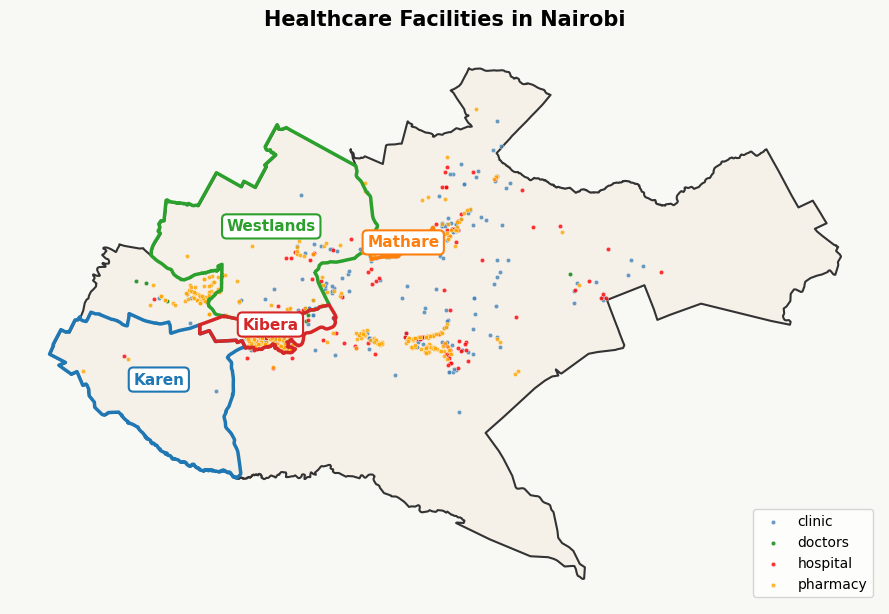

In [37]:
# Quick overview map
fig, ax = plt.subplots(figsize=(9, 9), facecolor='#f8f8f5')
nairobi.plot(ax=ax, color='#f5f0e8', edgecolor='#333', linewidth=1.5)

color_map = {'hospital': 'red', 'clinic': 'steelblue', 'pharmacy': 'orange', 'doctors': 'green'}
for fclass, grp in nairobi_health.groupby('fclass'):
    grp.plot(ax=ax, color=color_map.get(fclass, 'grey'), markersize=10,
             label=fclass, alpha=0.8, edgecolor='white', linewidth=0.3)

for name, gdf in areas.items():
    gdf.plot(ax=ax, color='none', edgecolor=area_colors[name], linewidth=2.5)
    c = gdf.geometry.centroid.iloc[0]
    ax.annotate(name, xy=(c.x, c.y), fontsize=11, fontweight='bold',
                color=area_colors[name], ha='center',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                          edgecolor=area_colors[name], linewidth=1.5))

ax.legend(loc='lower right', frameon=True)
ax.set_title('Healthcare Facilities in Nairobi', fontsize=15, fontweight='bold', pad=12)
ax.axis('off')
plt.tight_layout()
plt.savefig('../outputs/figures/01_nairobi_overview.png', dpi=200, bbox_inches='tight')
plt.show()

## Step 2 — H3 Hexagon Grid

In [38]:
def poly_to_hexagons(polygon, resolution, crs='EPSG:4326'):
    # H3 needs GeoJSON with (lng, lat) order
    coords = list(polygon.exterior.coords)
    geojson = {'type': 'Polygon', 'coordinates': [coords]}
    hex_ids = h3.polyfill(geojson, resolution, geo_json_conformant=True)

    hexagons = []
    for h in hex_ids:
        boundary = h3.h3_to_geo_boundary(h, geo_json=True)
        hexagons.append({'hex_id': h, 'geometry': Polygon(boundary)})
    return gpd.GeoDataFrame(hexagons, crs=crs)

RESOLUTION = 9

# H3 needs WGS84 input
nairobi_wgs = nairobi.to_crs('EPSG:4326')
gdf_hex = poly_to_hexagons(nairobi_wgs.geometry.values[0], resolution=RESOLUTION)
print(f'Hexagon count: {len(gdf_hex)}')
gdf_hex.head()

Hexagon count: 6032


,hex_id,geometry
0,897a6e54ecfffff,"POLYGON ((36.75442 -1.34254, 36.75446 -1.34066..."
1,897a6e43573ffff,"POLYGON ((36.91176 -1.26521, 36.91179 -1.26333..."
2,897a6e55d0bffff,"POLYGON ((36.76151 -1.32024, 36.76155 -1.31836..."
3,897a6e54d53ffff,"POLYGON ((36.72093 -1.35792, 36.72097 -1.35604..."
4,897a6e54003ffff,"POLYGON ((36.78215 -1.36368, 36.78219 -1.3618,..."


In [39]:
# Count facilities per hexagon
nairobi_health_wgs = nairobi_health.to_crs('EPSG:4326')
hex_count = gpd.sjoin(nairobi_health_wgs, gdf_hex, predicate='within').groupby('hex_id').size()
gdf_hex['facility_cnt'] = gdf_hex['hex_id'].map(hex_count).fillna(0)

print(f'Hexagons with ≥1 facility: {(gdf_hex["facility_cnt"] > 0).sum()}')
print(gdf_hex['facility_cnt'].describe())

Hexagons with ≥1 facility: 353
count    6032.000000
mean        0.162135
std         1.017296
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max        25.000000
Name: facility_cnt, dtype: float64


In [40]:
# Extract population from WorldPop raster
pop_stats = zonal_stats(gdf_hex, POP_RASTER, stats=['sum'], nodata=-99999)
gdf_hex['population'] = [s['sum'] if s['sum'] else 0 for s in pop_stats]

# Per-10k metric (only where population > 500 to filter low-density noise)
gdf_hex['per_10k'] = np.where(
    gdf_hex['population'] > 500,
    gdf_hex['facility_cnt'] / gdf_hex['population'] * 10_000,
    np.nan
)

print('Population stats:'); print(gdf_hex['population'].describe())
print('Per-10k stats:');     print(gdf_hex['per_10k'].describe())

Population stats:
count     6032.000000
mean       844.260810
std       1263.022122
min          0.000000
25%          9.604208
50%        272.087097
75%       1174.570801
max      12643.400391
Name: population, dtype: float64
Per-10k stats:
count    2392.000000
mean        1.951023
std         8.307183
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max       123.916312
Name: per_10k, dtype: float64


## Step 3 — Density Map: Facilities per 10,000 People

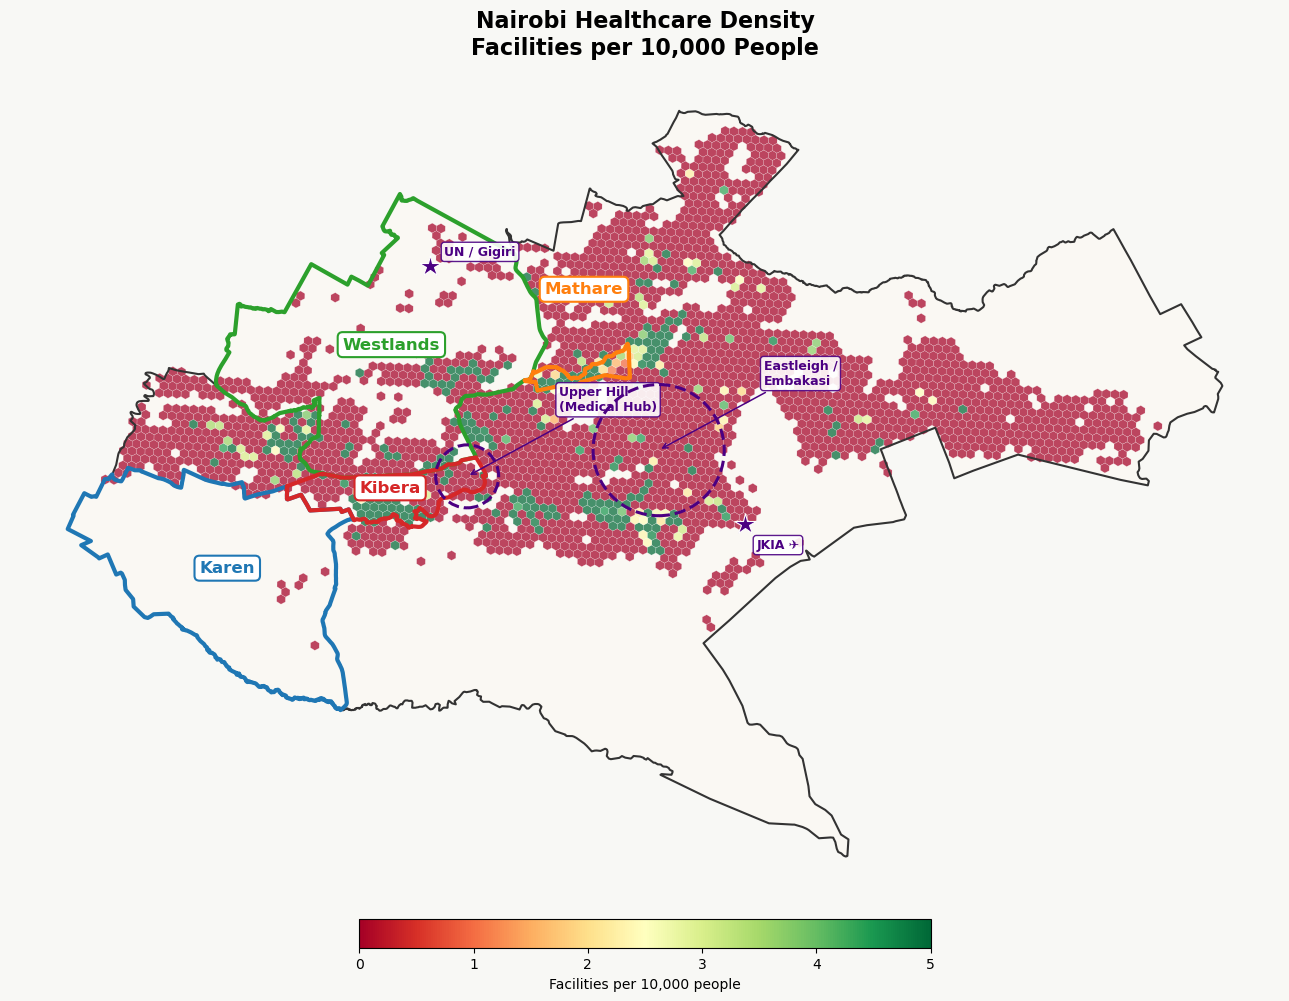

In [41]:
from matplotlib.patches import Circle

fig, ax = plt.subplots(figsize=(13, 13), facecolor='#f8f8f5')

nairobi.to_crs('EPSG:4326').plot(ax=ax, color='#faf8f3', edgecolor='none')

gdf_hex_plot = gdf_hex[gdf_hex['per_10k'].notna()].copy()
gdf_hex_plot.plot(
    column='per_10k', cmap='RdYlGn',
    ax=ax, alpha=0.72, legend=True,
    legend_kwds={'label': 'Facilities per 10,000 people',
                 'shrink': 0.45, 'orientation': 'horizontal', 'pad': 0.02},
    edgecolor='white', linewidth=0.2,
    vmin=0, vmax=5
)

nairobi.to_crs('EPSG:4326').plot(ax=ax, color='none', edgecolor='#333', linewidth=1.5)

label_offsets = {'Mathare': (0.0, 0.030)}  # push Mathare label up, away from Upper Hill

for name, gdf in areas.items():
    gdf.to_crs('EPSG:4326').plot(ax=ax, color='none',
                                  edgecolor=area_colors[name], linewidth=3)
    c = gdf.to_crs('EPSG:4326').geometry.centroid.iloc[0]
    dx, dy = label_offsets.get(name, (0, 0))
    ax.annotate(name, xy=(c.x + dx, c.y + dy), fontsize=12, fontweight='bold',
                color=area_colors[name], ha='center',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                          edgecolor=area_colors[name], linewidth=1.5))

# --- Dashed circles for landmark districts ---
landmark_circles = [
    # (lon, lat, radius, label, label_lon, label_lat, ha)
    (36.817, -1.300, 0.012, 'Upper Hill\n(Medical Hub)', 36.852, -1.275, 'left'),
    (36.890, -1.290, 0.025, 'Eastleigh /\nEmbakasi',    36.930, -1.265, 'left'),
]
for lon, lat, r, label, llon, llat, ha in landmark_circles:
    ax.add_patch(Circle((lon, lat), radius=r,
                         edgecolor='#4b0082', facecolor='none',
                         linewidth=2.2, linestyle='--', zorder=5))
    ax.annotate(label, xy=(lon, lat), xytext=(llon, llat),
                fontsize=9, fontweight='bold', color='#4b0082', ha=ha,
                arrowprops=dict(arrowstyle='->', color='#4b0082', lw=1.1),
                bbox=dict(boxstyle='round,pad=0.25', facecolor='white',
                          edgecolor='#4b0082', linewidth=1, alpha=0.9))

# --- Star markers for point landmarks ---
point_landmarks = {
    'UN / Gigiri': (36.803, -1.220),
    'JKIA ✈':      (36.923, -1.318),
}
offsets = {
    'UN / Gigiri': (10,  8),
    'JKIA ✈':      (8, -18),
}
for label, (lon, lat) in point_landmarks.items():
    ax.plot(lon, lat, marker='*', color='#4b0082', markersize=16,
            markeredgecolor='white', markeredgewidth=0.8, zorder=5)
    ax.annotate(label, xy=(lon, lat), xytext=offsets[label],
                textcoords='offset points', fontsize=9, fontweight='bold',
                color='#4b0082',
                bbox=dict(boxstyle='round,pad=0.25', facecolor='white',
                          edgecolor='#4b0082', linewidth=1, alpha=0.9))

ax.set_title('Nairobi Healthcare Density\nFacilities per 10,000 People',
             fontsize=16, fontweight='bold', pad=14)
ax.axis('off')
plt.tight_layout()
plt.savefig('../outputs/figures/02_density_per10k.png', dpi=200, bbox_inches='tight')
plt.show()

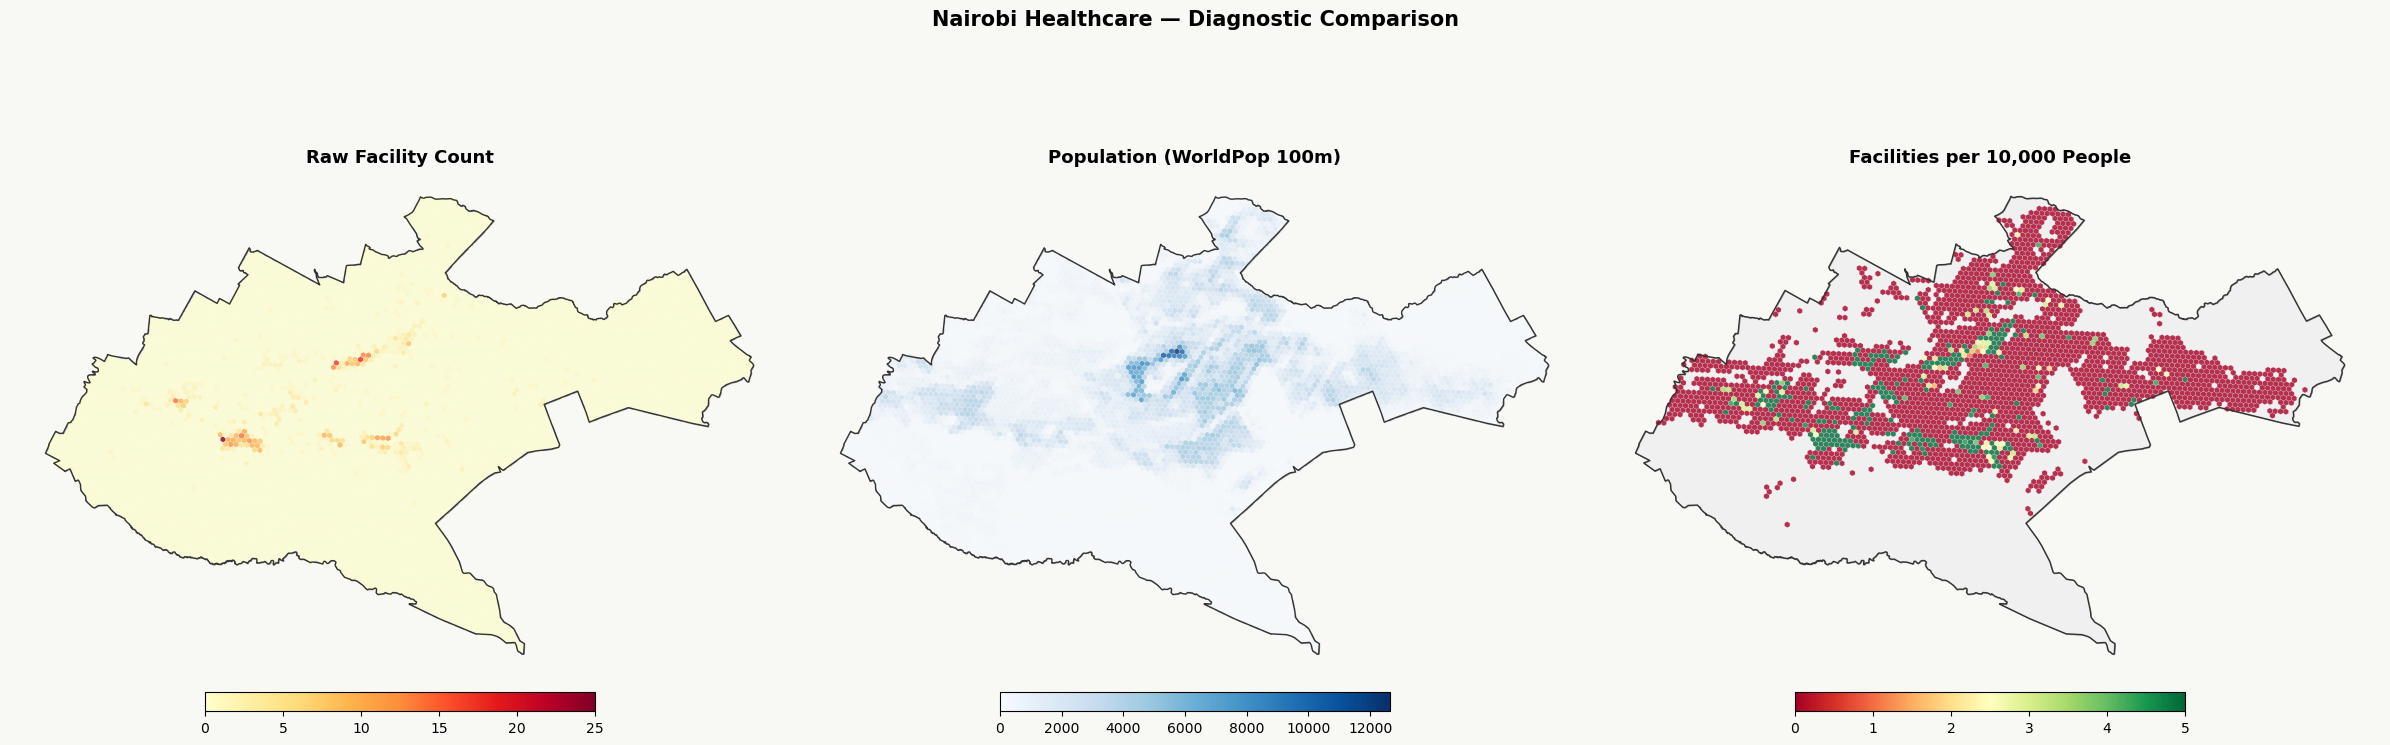

In [42]:
# Diagnostic: raw facility count / population / per_10k side by side
fig, axes = plt.subplots(1, 3, figsize=(24, 8), facecolor='#f8f8f5')

panels = [
    ('facility_cnt', 'Raw Facility Count',         'YlOrRd', None, None),
    ('population',   'Population (WorldPop 100m)',  'Blues',  None, None),
    ('per_10k',      'Facilities per 10,000 People','RdYlGn', 0,    5   ),
]

for ax, (col, title, cmap, vmin, vmax) in zip(axes, panels):
    nairobi.to_crs('EPSG:4326').plot(ax=ax, color='#f0f0f0', edgecolor='#999', linewidth=0.8)

    plot_data = gdf_hex[gdf_hex[col].notna()].copy()
    kwargs = dict(column=col, cmap=cmap, ax=ax, alpha=0.8,
                  legend=True, edgecolor='white', linewidth=0.15,
                  legend_kwds={'shrink': 0.5, 'orientation': 'horizontal', 'pad': 0.02})
    if vmin is not None:
        kwargs['vmin'] = vmin
        kwargs['vmax'] = vmax
    plot_data.plot(**kwargs)

    nairobi.to_crs('EPSG:4326').plot(ax=ax, color='none', edgecolor='#333', linewidth=1)
    ax.set_title(title, fontsize=13, fontweight='bold', pad=8)
    ax.axis('off')

plt.suptitle('Nairobi Healthcare — Diagnostic Comparison', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../outputs/figures/00_diagnostic_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 4 — Walking Network & Multi-source Dijkstra

In [43]:
import os

WALK_SPEED_MS = 5 * 1000 / 3600   # 5 km/h in m/s

if os.path.exists(WALK_GRAPH):
    print('Loading saved walk graph...')
    G_walk = ox.load_graphml(WALK_GRAPH)
else:
    print('Downloading walk network (may take 3–5 min)...')
    G_walk = ox.graph_from_polygon(nairobi_poly, network_type='walk', simplify=True)
    # Add travel time (seconds) to each edge
    for u, v, k, data in G_walk.edges(keys=True, data=True):
        data['travel_time'] = data['length'] / WALK_SPEED_MS
    ox.save_graphml(G_walk, WALK_GRAPH)
    print('Saved to', WALK_GRAPH)

print(f'Nodes: {len(G_walk.nodes):,}   Edges: {len(G_walk.edges):,}')

Loading saved walk graph...
Nodes: 72,265   Edges: 176,850


In [44]:
def multi_source_walk_time(G, facility_gdf):
    fac_wgs = facility_gdf.to_crs('EPSG:4326')
    fac_nodes = list(set(ox.distance.nearest_nodes(
        G, X=fac_wgs.geometry.x.values, Y=fac_wgs.geometry.y.values
    )))
    print(f'  Facility nodes: {len(fac_nodes)}')

    # Super-source trick: add a virtual node connected to all facility nodes at cost 0
    G2 = G.copy()
    SUPER = '__super__'
    G2.add_node(SUPER)
    for n in fac_nodes:
        G2.add_edge(SUPER, n, travel_time=0)

    times = nx.single_source_dijkstra_path_length(G2, source=SUPER, weight='travel_time')
    times.pop(SUPER, None)
    return times

# --- To nearest hospital ---
hospitals = nairobi_health[nairobi_health['fclass'] == 'hospital']
print(f'Hospitals: {len(hospitals)}')
times_hospital = multi_source_walk_time(G_walk, hospitals)

# --- To nearest any facility ---
print(f'All facilities: {len(nairobi_health)}')
times_any = multi_source_walk_time(G_walk, nairobi_health)

Hospitals: 146
  Facility nodes: 136
All facilities: 980
  Facility nodes: 729


In [45]:
# Map hexagon centroids → nearest walk-network node → travel time
hex_wgs = gdf_hex.to_crs('EPSG:4326')
centroids = hex_wgs.geometry.centroid

nearest_nodes = ox.distance.nearest_nodes(
    G_walk, X=centroids.x.values, Y=centroids.y.values
)

gdf_hex['walk_min_hospital'] = [
    times_hospital.get(n, np.nan) / 60 for n in nearest_nodes
]
gdf_hex['walk_min_any'] = [
    times_any.get(n, np.nan) / 60 for n in nearest_nodes
]

print('Walk time to hospital (minutes):')
print(gdf_hex['walk_min_hospital'].describe())

Walk time to hospital (minutes):
count    6032.000000
mean       58.130109
std        50.869683
min         0.000000
25%        21.326142
50%        43.085492
75%        82.454225
max       329.693483
Name: walk_min_hospital, dtype: float64


## Step 5 — Walk-Time Accessibility Maps

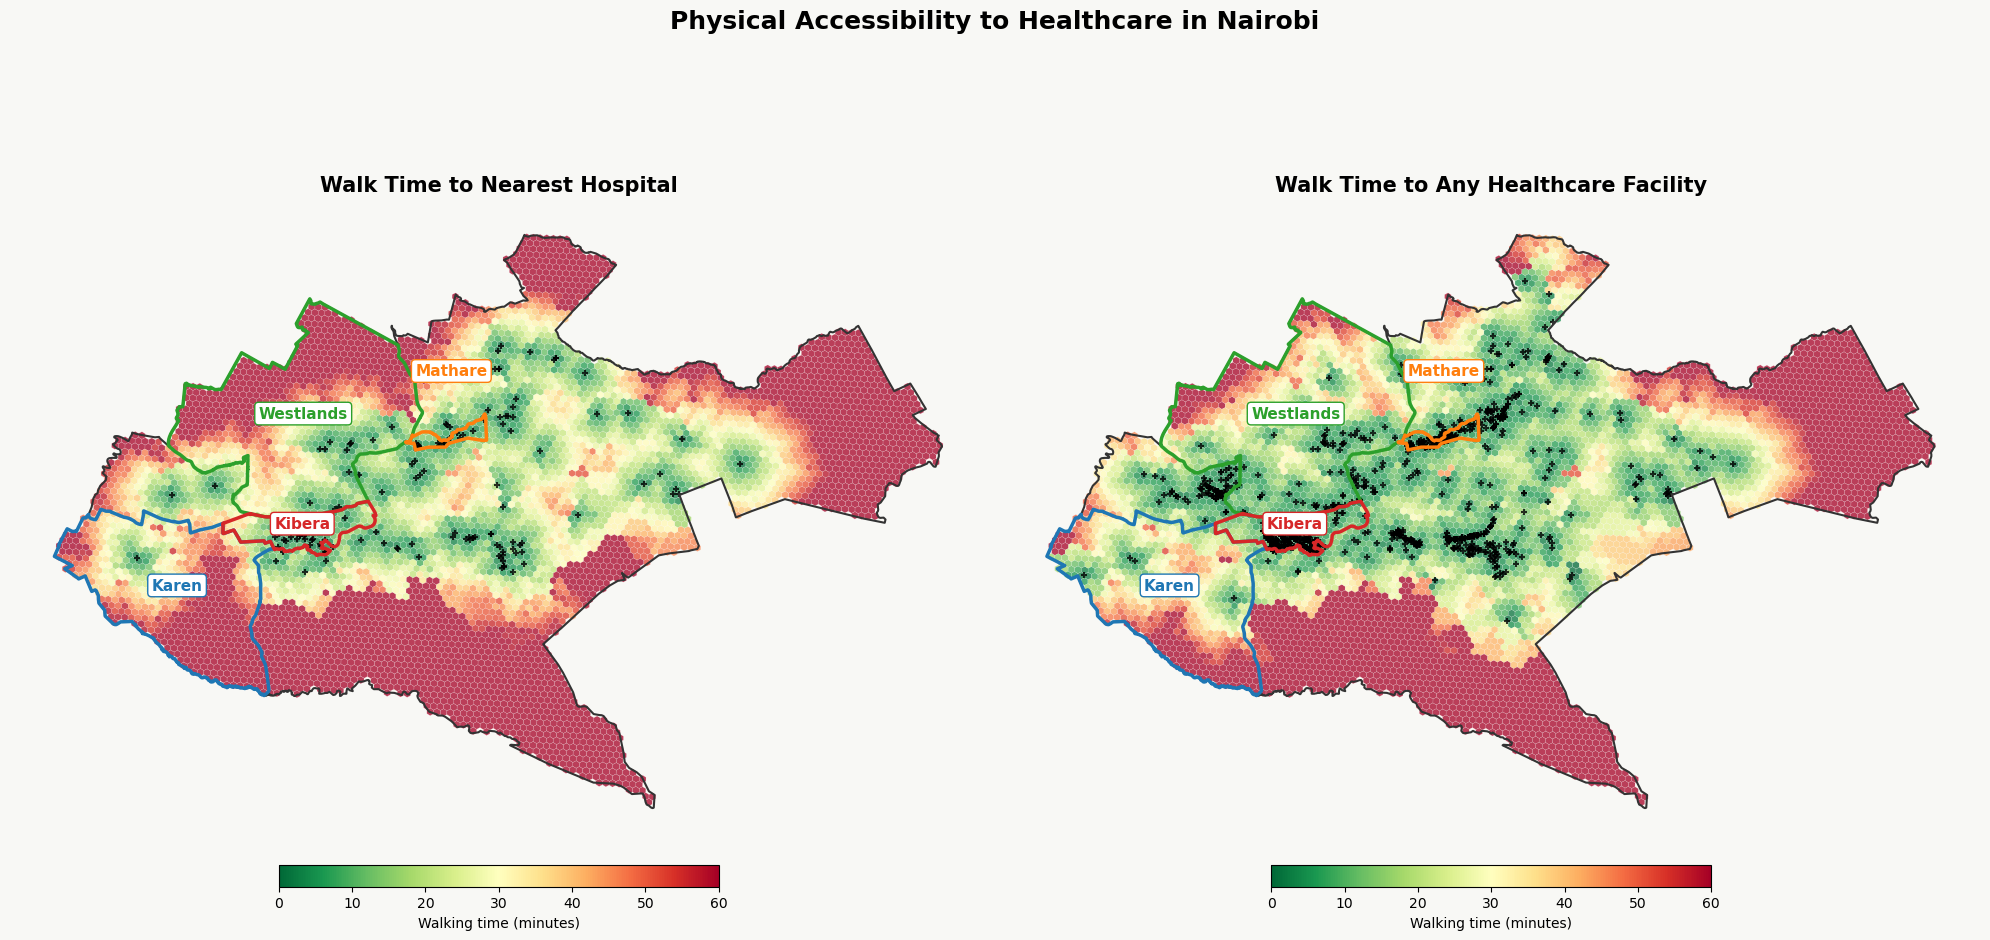

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(20, 10), facecolor='#f8f8f5')

panels = [
    ('walk_min_hospital', 'Walk Time to Nearest Hospital', hospitals),
    ('walk_min_any',      'Walk Time to Any Healthcare Facility', nairobi_health),
]

label_offsets = {'Mathare': (0.0, 0.030)}

for ax, (col, title, pts) in zip(axes, panels):
    nairobi.to_crs('EPSG:4326').plot(ax=ax, color='#faf8f3', edgecolor='none')

    plot_data = gdf_hex[gdf_hex[col].notna()].copy()
    plot_data[col] = plot_data[col].clip(upper=90)

    plot_data.plot(
        column=col, cmap='RdYlGn_r',
        vmin=0, vmax=60,
        ax=ax, alpha=0.75, legend=True,
        legend_kwds={'label': 'Walking time (minutes)',
                     'shrink': 0.45, 'orientation': 'horizontal', 'pad': 0.03},
        edgecolor='white', linewidth=0.15
    )

    pts.to_crs('EPSG:4326').plot(ax=ax, color='black', markersize=20,
                                  marker='+', linewidth=1.5, alpha=0.8)

    nairobi.to_crs('EPSG:4326').plot(ax=ax, color='none', edgecolor='#333', linewidth=1.5)

    for name, gdf in areas.items():
        gdf.to_crs('EPSG:4326').plot(ax=ax, color='none',
                                      edgecolor=area_colors[name], linewidth=2.5)
        c = gdf.to_crs('EPSG:4326').geometry.centroid.iloc[0]
        dx, dy = label_offsets.get(name, (0, 0))
        ax.annotate(name, xy=(c.x + dx, c.y + dy), fontsize=11, fontweight='bold',
                    color=area_colors[name], ha='center',
                    bbox=dict(boxstyle='round,pad=0.25', facecolor='white',
                              edgecolor=area_colors[name]))

    ax.set_title(title, fontsize=15, fontweight='bold', pad=10)
    ax.axis('off')

plt.suptitle('Physical Accessibility to Healthcare in Nairobi',
             fontsize=18, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../outputs/figures/03_walk_time.png', dpi=200, bbox_inches='tight')
plt.show()

## Step 6 — Per-Area Summary Statistics

In [47]:
results = []
for name, gdf in areas.items():
    area_poly = gdf.to_crs('EPSG:4326').geometry.values[0]
    area_km2  = gdf.to_crs('EPSG:32737').geometry.area.iloc[0] / 1e6

    fac_in = nairobi_health[nairobi_health.to_crs('EPSG:4326').within(area_poly)]
    hosp_in = fac_in[fac_in['fclass'] == 'hospital']

    pop_stat = zonal_stats(gdf.to_crs('EPSG:4326'), POP_RASTER, stats=['sum'])
    pop = pop_stat[0]['sum'] or 0

    hex_in = gdf_hex[gdf_hex.to_crs('EPSG:4326').geometry.centroid.within(area_poly)]
    hex_valid = hex_in.dropna(subset=['walk_min_hospital'])

    if len(hex_valid) > 0 and hex_valid['population'].sum() > 0:
        w_time = np.average(hex_valid['walk_min_hospital'], weights=hex_valid['population'])
        pop_total = hex_valid['population'].sum()
        pct15 = hex_valid[hex_valid['walk_min_hospital'] <= 15]['population'].sum() / pop_total * 100
        pct30 = hex_valid[hex_valid['walk_min_hospital'] <= 30]['population'].sum() / pop_total * 100
        pct60 = hex_valid[hex_valid['walk_min_hospital'] <= 60]['population'].sum() / pop_total * 100
    else:
        w_time = pct15 = pct30 = pct60 = np.nan

    results.append({
        'Area':                       name,
        'Area (km\u00b2)':            round(area_km2, 1),
        'Population':                 int(pop),
        'All Facilities':             len(fac_in),
        'Hospitals':                  len(hosp_in),
        'Facilities / 10k':           round(len(fac_in) / pop * 10000, 2) if pop > 0 else np.nan,
        'Avg Walk to Hospital (min)': round(w_time, 1),
        '% Pop < 15 min':             round(pct15, 1),
        '% Pop < 30 min':             round(pct30, 1),
        '% Pop < 60 min':             round(pct60, 1),
    })

df_results = pd.DataFrame(results)
df_results.to_csv('../outputs/tables/area_summary.csv', index=False)

from IPython.display import display

gradient_cols = ['Facilities / 10k', '% Pop < 15 min', '% Pop < 30 min', '% Pop < 60 min']
reverse_cols  = ['Avg Walk to Hospital (min)']

styled = (
    df_results.style
    .background_gradient(subset=gradient_cols, cmap='RdYlGn', axis=0)
    .background_gradient(subset=reverse_cols,  cmap='RdYlGn_r', axis=0)
    .format({
        'Population':                 '{:,}',
        'Facilities / 10k':           '{:.2f}',
        'Avg Walk to Hospital (min)': '{:.1f} min',
        '% Pop < 15 min':             '{:.1f}%',
        '% Pop < 30 min':             '{:.1f}%',
        '% Pop < 60 min':             '{:.1f}%',
    })
    .set_caption('Healthcare Accessibility Summary \u2014 4 Study Areas')
    .set_properties(**{'text-align': 'center', 'font-size': '13px', 'padding': '6px 12px'})
    .set_table_styles([
        {'selector': 'caption',
         'props': [('font-size', '15px'), ('font-weight', 'bold'),
                   ('color', '#222'), ('padding-bottom', '10px')]},
        {'selector': 'th',
         'props': [('background-color', '#4b0082'), ('color', 'white'),
                   ('font-weight', 'bold'), ('text-align', 'center'),
                   ('font-size', '12px'), ('padding', '8px 12px')]},
        {'selector': 'td:first-child',
         'props': [('font-weight', 'bold'), ('text-align', 'left')]},
    ])
    .hide(axis='index')
)
display(styled)

Area,Area (km²),Population,All Facilities,Hospitals,Facilities / 10k,Avg Walk to Hospital (min),% Pop < 15 min,% Pop < 30 min,% Pop < 60 min
Karen,71.300000,"101,925",4,1,0.39,55.7 min,3.8%,18.9%,55.2%
Westlands,97.500000,"324,665",75,12,2.31,38.3 min,24.8%,45.7%,78.3%
Kibera,12.700000,"178,568",246,31,13.78,10.8 min,74.0%,93.9%,100.0%
Mathare,3.000000,"193,786",129,18,6.66,6.2 min,99.1%,100.0%,100.0%


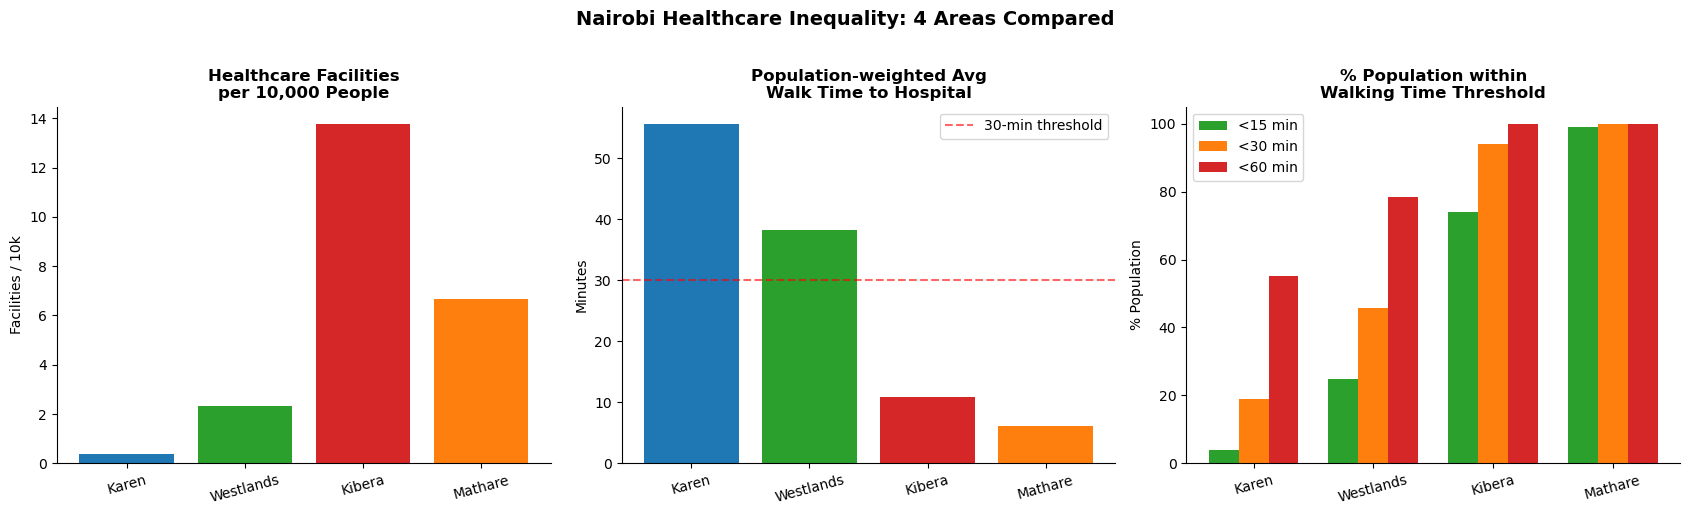

In [50]:
# Comparison bar charts
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
colors_list = [area_colors[n] for n in df_results['Area']]

axes[0].bar(df_results['Area'], df_results['Facilities / 10k'], color=colors_list)
axes[0].set_title('Healthcare Facilities\nper 10,000 People', fontweight='bold')
axes[0].set_ylabel('Facilities / 10k')

axes[1].bar(df_results['Area'], df_results['Avg Walk to Hospital (min)'], color=colors_list)
axes[1].axhline(30, color='red', linestyle='--', alpha=0.6, label='30-min threshold')
axes[1].set_title('Population-weighted Avg\nWalk Time to Hospital', fontweight='bold')
axes[1].set_ylabel('Minutes')
axes[1].legend()

x = np.arange(len(df_results))
w = 0.25
axes[2].bar(x - w, df_results['% Pop < 15 min'], w, label='<15 min', color='#2ca02c')
axes[2].bar(x,     df_results['% Pop < 30 min'], w, label='<30 min', color='#ff7f0e')
axes[2].bar(x + w, df_results['% Pop < 60 min'], w, label='<60 min', color='#d62728')
axes[2].set_xticks(x); axes[2].set_xticklabels(df_results['Area'])
axes[2].set_title('% Population within\nWalking Time Threshold', fontweight='bold')
axes[2].set_ylabel('% Population')
axes[2].legend()

for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='x', rotation=15)

plt.suptitle('Nairobi Healthcare Inequality: 4 Areas Compared',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/figures/04_area_comparison.png', dpi=200, bbox_inches='tight')
plt.show()

## Key Findings
1. Informal Settlements Have More Facilities per Capita, But for the Wrong Reasons
Kibera (12.64/10k) and Mathare (6.66/10k) record far higher facility density than Karen (0.39/10k) and Westlands (2.31/10k). This reflects intensive NGO and aid-sector clinic provision in informal areas, combined with the compact geography of these settlements. However, WorldPop likely underestimates residential population in high-density tin-roof areas, which may artificially inflate per-capita figures.

2. Wealthy Suburbs Have the Worst Walking Accessibility
Karen residents face an average 55.7-minute walk to the nearest hospital, with only 3.8% of the population within 15 minutes. This is not because Karen lacks healthcare. It reflects car dependency: residents drive to Upper Hill's private medical hub (~20 min by car) rather than walk. Walking accessibility is a poor proxy for effective access in low-density, car-oriented suburbs.

3. Quantity Does Not Equal Quality
Kibera's 281 facilities are predominantly small clinics and pharmacies. Karen's single mapped hospital, while few in number, represents access to Nairobi's concentration of high-end private specialists in Upper Hill. The real healthcare inequality in Nairobi lies in quality and specialisation, a dimension this analysis does not directly measure.

4. Compact Urban Form Drives Accessibility
Mathare (3.0 km²) achieves 100% population coverage within 15 minutes purely due to its small geographic size and density but not necessarily superior provision. Urban form and settlement compactness are as important as facility count in determining walking accessibility.

5. The NGO Effect and Its Limits
High facility counts in informal settlements are partly a legacy of international NGO and government health programmes targeting the urban poor. However, OSM data quality is uneven: NGO-run facilities in Kibera are well-mapped, while informal providers (traditional healers, unregistered clinics) are almost entirely absent from the dataset, meaning true facility counts are likely higher still, especially in Mathare.

## Limitations

- OSM may underrepresent informal healthcare providers in Kibera/Mathare; actual facility counts in informal settlements are likely higher than recorded
- WorldPop likely underestimates population in dense informal settlements (high-density tin-roof structures)
- Walk-time assumes 5 km/h on all mapped paths; narrow informal settlement alleyways may be slower in practice
- Unmapped footpaths in OSM will bias Kibera/Mathare walk times upward
- The Eastleigh/Embakasi corridor shows elevated facility-per-capita values, likely because WorldPop (a residential population model) underestimates daytime workers near JKIA and commercial zones; these readings should not be interpreted as genuine high accessibility for residents
- Analysis is limited to walking accessibility; car-dependent areas such as Karen and Westlands have better effective access to Upper Hill's medical hub than walk-time alone suggests

## AI Use Declaration

This project used Claude (Anthropic) as an AI assistant for coding support (debugging, analysis, visualisation) and language polishing. All substantive research decisions, including research design, case selection, interpretation, and conclusions, were made independently by the author.

The project was initially designed as a provincial-level comparison within China. During the research process, the study scope was revised due to two methodological concerns: 
- substantial data limitations that prevented reliable cross-provincial comparison
- the mismatch between provincial-scale analysis and the project’s focus on intra-urban healthcare accessibility inequality

Nairobi was ultimately selected because of its relatively well-documented open-source spatial data, its clear socioeconomic differentiation between formal and informal settlements, and its relevance as a representative case of healthcare accessibility inequality in a developing-country urban context.